In [12]:
# 공통 셀: 모델/토크나이저/유틸 (eval, inference 공용)

import torch
import torch.nn as nn
import numpy as np
from pathlib import Path

from transformers import WhisperProcessor, WhisperTokenizerFast, WhisperFeatureExtractor, WhisperForConditionalGeneration

# =========================
# 경로 / 기기 설정
# =========================
PROJECT_ROOT = Path("/home/alpaco/jws/whisper_only")
CKPT_DIR = PROJECT_ROOT / "checkpoints_stage2" / "checkpoint-3126"  # 여기만 바꾸면 됨

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] device:", DEVICE)

# =========================
# Processor / Tokenizer 로드
#   - 학습 때와 동일한 베이스 모델 이름 사용
# =========================
MODEL_NAME = "openai/whisper-small"

# processor = WhisperProcessor.from_pretrained(MODEL_NAME)
# feature_extractor: WhisperFeatureExtractor = processor.feature_extractor
# tokenizer: WhisperTokenizerFast = processor.tokenizer

feature_extractor = WhisperFeatureExtractor.from_pretrained(MODEL_NAME)
tokenizer = WhisperTokenizerFast.from_pretrained(
    MODEL_NAME,
    language="Korean",
    task="transcribe",
    add_prefix_space=True,   # ★ 중요
)
processor = WhisperProcessor(feature_extractor=feature_extractor, tokenizer=tokenizer)

print("sampling_rate:", feature_extractor.sampling_rate)
print("pad_token_id :", tokenizer.pad_token_id)

# =========================
# Filler 단어 / 전처리 함수 (학습 때와 동일 컨셉)
# =========================
import re

FILLER_WORDS = ["음", "어", "아", "그러니까", "그게", "저", "뭐랄까", "에"]
FILLER_SET   = set(FILLER_WORDS)

def normalize_korean_token(tok: str) -> str:
    tok = tok.strip()
    tok = re.sub(r"[.,?!…~]+", "", tok)
    return tok

def count_fillers_from_text(text: str):
    """
    단순 lexical 방식: 디코딩된 텍스트에서 filler word를 세는 함수
    (filler head 결과와 비교할 때 참고용)
    """
    words = text.strip().split()
    norm = [normalize_korean_token(w) for w in words]
    mask = [int(w in FILLER_SET) for w in norm]
    return {
        "words": words,
        "norm_words": norm,
        "filler_mask": mask,
        "filler_count": sum(mask),
    }

# =========================
# Whisper + Filler Head 구조 (학습 코드와 동일)
#   - Stage2 whisper_train.py의 구조를 그대로 복사
# =========================
class WhisperWithFillerHead(WhisperForConditionalGeneration):
    def __init__(self, config):
        super().__init__(config)

        # decoder hidden state → 2-class (non-filler / filler)
        self.filler_classifier = nn.Linear(config.d_model, 2)

        # 항상 hidden states 출력
        self.config.output_hidden_states = True

        # inference에서는 loss는 크게 중요하지 않지만,
        # 구조를 맞추기 위해 기본 cross-entropy를 둡니다.
        self.filler_loss_fct = nn.CrossEntropyLoss(
            ignore_index=-100,
        )

    def forward(
        self,
        input_features=None,
        attention_mask=None,
        decoder_input_ids=None,
        decoder_attention_mask=None,
        labels=None,
        filler_labels=None,
        **kwargs,
    ):
        # Trainer가 넘겼던 num_items_in_batch 등이 들어오는 경우 방어
        if "num_items_in_batch" in kwargs:
            kwargs.pop("num_items_in_batch")

        # Whisper 기본 forward (ASR loss 포함)
        outputs = super().forward(
            input_features=input_features,
            attention_mask=attention_mask,
            decoder_input_ids=decoder_input_ids,
            decoder_attention_mask=decoder_attention_mask,
            labels=labels,
            **kwargs,
        )

        total_loss = outputs.loss
        filler_logits = None
        filler_loss = None

        # decoder hidden states → filler head
        if outputs.decoder_hidden_states is not None:
            last_hidden = outputs.decoder_hidden_states[-1]       # (B, T, d_model)
            filler_logits = self.filler_classifier(last_hidden)   # (B, T, 2)

            # 학습이 아니라면 filler_labels는 보통 None이므로 loss는 사용 X
            if filler_labels is not None:
                B, T, C = filler_logits.shape
                filler_loss = self.filler_loss_fct(
                    filler_logits.view(B * T, C),
                    filler_labels.view(B * T),
                )
                if total_loss is not None:
                    total_loss = total_loss + filler_loss
                else:
                    total_loss = filler_loss

        outputs.loss = total_loss
        outputs.filler_logits = filler_logits
        outputs.filler_loss = filler_loss
        return outputs

# =========================
# Stage2 checkpoint 로드 + generation_config 패치
# =========================
print("[INFO] Loading Stage2 checkpoint from:", CKPT_DIR)
model = WhisperWithFillerHead.from_pretrained(str(CKPT_DIR))
model.to(DEVICE)
model.eval()

# Whisper의 언어 강제 기능을 비활성화해서 lang_to_id 에러 방지
gen_cfg = model.generation_config
gen_cfg.forced_decoder_ids = None   # 어떤 언어 토큰도 강제하지 않음
gen_cfg.language = None             # language 강제 비활성화
gen_cfg.task = None                 # task 강제 비활성화

# config에도 동일하게 맞춰주면 안전
model.config.forced_decoder_ids = None

print("[INFO] Model & generation_config patched for inference.")


[INFO] device: cuda
sampling_rate: 16000
pad_token_id : 50257
[INFO] Loading Stage2 checkpoint from: /home/alpaco/jws/whisper_only/checkpoints_stage2/checkpoint-3126


Some weights of the model checkpoint at /home/alpaco/jws/whisper_only/checkpoints_stage2/checkpoint-3126 were not used when initializing WhisperWithFillerHead: ['filler_loss_fct.weight']
- This IS expected if you are initializing WhisperWithFillerHead from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WhisperWithFillerHead from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


[INFO] Model & generation_config patched for inference.


In [13]:
# 오디오 로딩 함수 (모노 + 16kHz 리샘플)
import soundfile as sf
import librosa

def load_audio_mono_16k(path, target_sr=16000):
    wav, sr = sf.read(path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)  # stereo → mono
    if sr != target_sr:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=target_sr)
    return wav, target_sr


In [19]:
# 1. lexical 방식: 최종 텍스트에서 FILLER_WORDS를 직접 세는 방식

# 2. filler head 방식 (token-level):

# 먼저 generate로 토큰 시퀀스를 얻고

# 그 토큰 시퀀스를 labels로 넣어서 한 번 더 forward를 돌려 filler_logits를 얻은 뒤

# 토큰별 filler 확률이 0.5 이상이면 filler로 카운트
def transcribe_and_count_filler_from_wav(
    wav_path: str,
    # max_length: int = 225,
    filler_threshold: float = 0.5,
):
    # 1) 오디오 로드
    audio, sr = load_audio_mono_16k(
        wav_path,
        target_sr=feature_extractor.sampling_rate,
    )

    # 2) Whisper input_features 생성
    inputs = feature_extractor(
        audio,
        sampling_rate=sr,
        return_tensors="pt",
    )
    input_features = inputs.input_features.to(DEVICE)   # (1, 80, T)

    # 3) ASR: generate로 디코딩
    with torch.no_grad():
        gen_ids = model.generate(
            input_features=input_features,
            # max_length=max_length,
        )

    # 텍스트 디코딩
    text = tokenizer.decode(gen_ids[0], skip_special_tokens=True)

    # 4) lexical filler 카운트
    lex = count_fillers_from_text(text)

    # 5) filler head 기반 토큰 단위 카운트
    with torch.no_grad():
        # teacher forcing처럼 gen_ids 전체를 labels로 넣어서
        # decoder hidden states를 모두 사용
        outputs = model(
            input_features=input_features,
            decoder_input_ids=gen_ids,
            labels=gen_ids,          # loss는 중요하지 않고, hidden state용
        )
        filler_logits = outputs.filler_logits      # (1, T, 2)
        probs = filler_logits.softmax(dim=-1)[0, :, 1].cpu().numpy()  # filler(클래스 1) 확률

    filler_token_mask = (probs >= filler_threshold).astype(np.int32)
    filler_token_count = int(filler_token_mask.sum())

    return {
        "text": text,
        "lexical": {
            "words": lex["words"],
            "norm_words": lex["norm_words"],
            "filler_mask": lex["filler_mask"],
            "filler_count": lex["filler_count"],
        },
        "token_level": {
            "filler_probs": probs,
            "filler_token_mask": filler_token_mask,
            "filler_token_count": filler_token_count,
        },
        "generated_ids": gen_ids[0].cpu().tolist(),
    }


In [25]:
test_wav = "/home/alpaco/jws/whisper_only/womantest.wav"  # 실제 테스트할 파일로 수정

res = transcribe_and_count_filler_from_wav(
    test_wav,
    # max_length=225,
    filler_threshold=0.5,
)

print("=== Transcription ===")
print(res["text"])
print()

print("=== Lexical Filler Count ===")
print("words:", res["lexical"]["words"])
print("filler_mask:", res["lexical"]["filler_mask"])
print("lexical filler_count:", res["lexical"]["filler_count"])
print()

print("=== Token-level Filler Head Count ===")
print("token-level filler_token_count:", res["token_level"]["filler_token_count"])
print("first 50 probs:", res["token_level"]["filler_probs"][:])


=== Transcription ===
 네. 타지역 업무도 가능합니다. 그러나 개인적으로 체력 분배에 관하여 굉장히 신경 쓰는 편이기 때문에 어 한 달에 한 두 번 정도에 출장은 가능하지만 너무 오래 타지역에 머물러야 한다던가 너무 자진 출장은 조금 피하는 성향이 피하는 경향이 있습니다. 어 그래서 출장을 간다면 시간은 짧게 가 가고 싶다는 개인적인 반응을

=== Lexical Filler Count ===
words: ['네.', '타지역', '업무도', '가능합니다.', '그러나', '개인적으로', '체력', '분배에', '관하여', '굉장히', '신경', '쓰는', '편이기', '때문에', '어', '한', '달에', '한', '두', '번', '정도에', '출장은', '가능하지만', '너무', '오래', '타지역에', '머물러야', '한다던가', '너무', '자진', '출장은', '조금', '피하는', '성향이', '피하는', '경향이', '있습니다.', '어', '그래서', '출장을', '간다면', '시간은', '짧게', '가', '가고', '싶다는', '개인적인', '반응을']
filler_mask: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
lexical filler_count: 2

=== Token-level Filler Head Count ===
token-level filler_token_count: 0
first 50 probs: [2.1845795e-04 1.5723126e-03 6.5293803e-05 2.6064539e-05 1.2333153e-04
 1.6165166e-05 1.9990138e-04 4.1680363e-05 7.8745688e-05 1.0833885e-04
 4.2437579e-04 2.0885898

In [8]:
def transcribe_and_count_filler_from_wav(
    wav_path: str,
    max_length: int = 225,
    filler_threshold: float = 0.5,
):
    """
    wav → 텍스트 + filler 카운트 + 단어 단위 filler 판정까지 반환.

    반환값:
      {
        "text": str,
        "lexical": {
            "words": [...],
            "norm_words": [...],
            "filler_mask": [...],         # lexical 기준 (사전 FILLER_WORDS)
            "filler_count": int,
        },
        "token_level": {
            "filler_probs": np.ndarray[T_token],
            "filler_token_mask": np.ndarray[T_token],   # (0/1)
            "token_word_ids": List[int or None],
        },
        "word_level": {
            "word_probs": List[float],     # 각 단어의 filler 확률 (ex: max token prob)
            "word_mask": List[int],        # 0/1, filler 여부
            "filler_words": List[str],     # filler로 판정된 단어 리스트
        },
        "generated_ids": List[int],
    }
    """

    # 1) 오디오 로드
    audio, sr = load_audio_mono_16k(
        wav_path,
        target_sr=feature_extractor.sampling_rate,
    )

    # 2) Whisper input_features 생성
    inputs = feature_extractor(
        audio,
        sampling_rate=sr,
        return_tensors="pt",
    )
    input_features = inputs.input_features.to(DEVICE)   # (1, 80, T)

    # 3) ASR: generate로 디코딩
    with torch.no_grad():
        gen_ids = model.generate(
            input_features=input_features,
            max_length=max_length,
        )

    # 텍스트 디코딩
    text = tokenizer.decode(gen_ids[0], skip_special_tokens=True)

    # 4) lexical filler 카운트 (사전 기반)
    lex = count_fillers_from_text(text)   # words, norm_words, filler_mask, filler_count

    # 5) filler head 기반: 단어 단위 판정
    #    - words를 is_split_into_words=True 로 다시 토크나이징
    enc = tokenizer(
        lex["words"],
        is_split_into_words=True,
        add_special_tokens=True,
        return_attention_mask=True,
        return_tensors="pt",
    )
    dec_input_ids = enc["input_ids"].to(DEVICE)          # (1, T_dec)
    attention_mask = enc["attention_mask"].to(DEVICE)    # (1, T_dec)
    word_ids = enc.word_ids()                            # 길이 T_dec, 각 토큰이 어느 단어에 속하는지

    with torch.no_grad():
        # labels=dec_input_ids 로 teacher forcing 방식 forward
        outputs = model(
            input_features=input_features,
            decoder_input_ids=dec_input_ids,
            decoder_attention_mask=attention_mask,
            labels=dec_input_ids,
        )
        filler_logits = outputs.filler_logits[0]   # (T_dec, 2)

    # 토큰 단위 filler 확률 (클래스 1)
    token_probs = filler_logits.softmax(dim=-1)[:, 1].cpu().numpy()  # (T_dec,)

    # 토큰 단위 mask (special 토큰 제외)
    token_mask = np.array([
        0 if wid is None else 1
        for wid in word_ids
    ], dtype=np.int32)

    # token-level filler 판정 (special 토큰은 항상 0)
    filler_token_mask = (token_probs >= filler_threshold).astype(np.int32) * token_mask

    # 6) 단어 단위로 aggregate
    n_words = len(lex["words"])
    word_probs = [0.0] * n_words
    word_counts = [0] * n_words

    # 각 단어에 할당된 토큰들의 확률을 모아서 max 또는 평균을 사용
    # 여기서는 max를 사용 (어떤 토큰이라도 filler 쪽으로 강하게 나오면 단어를 filler로 간주)
    for tok_idx, wid in enumerate(word_ids):
        if wid is None:
            continue
        if 0 <= wid < n_words:
            p = float(token_probs[tok_idx])
            if word_counts[wid] == 0:
                word_probs[wid] = p
            else:
                # max 기준 (원하면 평균으로 바꿔도 됨)
                word_probs[wid] = max(word_probs[wid], p)
            word_counts[wid] += 1

    word_mask = [
        1 if (word_counts[i] > 0 and word_probs[i] >= filler_threshold) else 0
        for i in range(n_words)
    ]
    filler_words = [w for w, m in zip(lex["words"], word_mask) if m == 1]

    return {
        "text": text,
        "lexical": {
            "words": lex["words"],
            "norm_words": lex["norm_words"],
            "filler_mask": lex["filler_mask"],
            "filler_count": lex["filler_count"],
        },
        "token_level": {
            "filler_probs": token_probs,               # 길이 T_dec
            "filler_token_mask": filler_token_mask,    # 길이 T_dec, 0/1
            "token_word_ids": word_ids,                # 각 토큰이 어느 단어인지
        },
        "word_level": {
            "word_probs": word_probs,                  # 길이 n_words
            "word_mask": word_mask,                    # 길이 n_words, 0/1
            "filler_words": filler_words,
        },
        "generated_ids": gen_ids[0].cpu().tolist(),
    }


In [9]:
test_wav = "/home/alpaco/jws/whisper_only/mantest.wav"  # 실제 파일로 수정

res = transcribe_and_count_filler_from_wav(
    test_wav,
    max_length=225,
    filler_threshold=0.5,   # 원하면 0.4/0.6 등으로 조절
)

print("=== Transcription ===")
print(res["text"])
print()

print("=== Lexical Filler (사전기반) ===")
print(list(zip(res["lexical"]["words"], res["lexical"]["filler_mask"])))
print("lexical filler_count:", res["lexical"]["filler_count"])
print()

print("=== Filler Head (Word-level) ===")
words = res["lexical"]["words"]
word_mask = res["word_level"]["word_mask"]
word_probs = res["word_level"]["word_probs"]

for w, m, p in zip(words, word_mask, word_probs):
    tag = "FILLER" if m == 1 else "NON"
    print(f"{w:10s}  | {tag:6s} | p={p:.3f}")

print()
print("filler_words (from head):", res["word_level"]["filler_words"])


=== Transcription ===


=== Lexical Filler (사전기반) ===
[]
lexical filler_count: 0

=== Filler Head (Word-level) ===

filler_words (from head): []


[INFO] 단어 개수: 0, 유효 단어(토큰>=1): 0


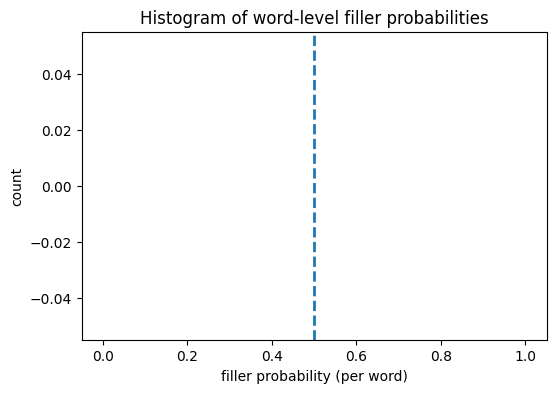

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# inference 결과에서 필요 정보 꺼내기
words          = res["lexical"]["words"]
word_probs     = np.array(res["word_level"]["word_probs"], dtype=float)      # (n_words,)
token_word_ids = res["token_level"]["token_word_ids"]                        # 길이 T_dec

n_words = len(words)

# 각 단어에 할당된 토큰 개수 계산 (토큰이 하나도 안 붙은 단어는 제외하기 위해)
word_counts = np.zeros(n_words, dtype=int)
for wid in token_word_ids:
    if wid is not None and 0 <= wid < n_words:
        word_counts[wid] += 1

valid_mask = word_counts > 0
valid_probs = word_probs[valid_mask]

print(f"[INFO] 단어 개수: {n_words}, 유효 단어(토큰>=1): {valid_mask.sum()}")

# 히스토그램 그리기
plt.figure(figsize=(6,4))
plt.hist(valid_probs, bins=20, alpha=0.7)
current_th = 0.5  # 지금 사용 중인 threshold (원하면 값 바꾸면서 보면 됨)
plt.axvline(current_th, linestyle='--', linewidth=2)
plt.xlabel("filler probability (per word)")
plt.ylabel("count")
plt.title("Histogram of word-level filler probabilities")
plt.show()


In [20]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd

def compute_word_metrics_for_thresholds(res, thresholds):
    """
    thresholds: iterable of float (ex: np.linspace(0.1, 0.9, 17))
    반환: pandas.DataFrame
      columns: [threshold, precision, recall, f1, accuracy, support]
    """
    words          = res["lexical"]["words"]
    lex_mask       = np.array(res["lexical"]["filler_mask"], dtype=int)   # 0/1 (사전기반)
    word_probs     = np.array(res["word_level"]["word_probs"], dtype=float)
    token_word_ids = res["token_level"]["token_word_ids"]

    n_words = len(words)

    # 각 단어에 할당된 토큰 개수
    word_counts = np.zeros(n_words, dtype=int)
    for wid in token_word_ids:
        if wid is not None and 0 <= wid < n_words:
            word_counts[wid] += 1

    valid = word_counts > 0
    y_true = lex_mask[valid]      # GT (lexical 기준)

    rows = []
    for th in thresholds:
        y_pred = ((word_probs >= th) & valid).astype(int)
        y_pred_valid = y_pred[valid]

        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred_valid,
            average="binary",
            pos_label=1,
            zero_division=0,
        )
        acc = accuracy_score(y_true, y_pred_valid)

        rows.append({
            "threshold": float(th),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "accuracy": float(acc),
            "support": int(len(y_true)),
        })

    df = pd.DataFrame(rows)
    return df

# 예시: 0.1 ~ 0.9까지 0.05 간격으로 스윕
thresholds = np.arange(0.1, 0.91, 0.05)
metrics_df = compute_word_metrics_for_thresholds(res, thresholds)
metrics_df


,threshold,precision,recall,f1,accuracy,support
0,0.10,0.400000,1.0,0.571429,0.950820,61
1,0.15,0.250000,0.5,0.333333,0.934426,61
2,0.20,0.250000,0.5,0.333333,0.934426,61
3,0.25,0.250000,0.5,0.333333,0.934426,61
4,0.30,0.250000,0.5,0.333333,0.934426,61
5,0.35,0.250000,0.5,0.333333,0.934426,61
6,0.40,0.333333,0.5,0.400000,0.950820,61
7,0.45,0.500000,0.5,0.500000,0.967213,61
8,0.50,0.000000,0.0,0.000000,0.950820,61
9,0.55,0.000000,0.0,0.000000,0.950820,61


In [21]:
best_row = metrics_df.iloc[metrics_df["f1"].idxmax()]
best_row


threshold     0.100000
precision     0.400000
recall        1.000000
f1            0.571429
accuracy      0.950820
support      61.000000
Name: 0, dtype: float64

In [ ]:
def build_error_table(res, threshold=0.5):
    """
    한 번의 inference 결과(res) 기준으로
    단어별 lexical vs head 기준을 비교한 테이블 생성.
    """
    words          = res["lexical"]["words"]
    norm_words     = res["lexical"]["norm_words"]
    lex_mask       = np.array(res["lexical"]["filler_mask"], dtype=int)   # 0/1
    word_probs     = np.array(res["word_level"]["word_probs"], dtype=float)
    token_word_ids = res["token_level"]["token_word_ids"]

    n_words = len(words)

    # 각 단어에 할당된 토큰 개수
    word_counts = np.zeros(n_words, dtype=int)
    for wid in token_word_ids:
        if wid is not None and 0 <= wid < n_words:
            word_counts[wid] += 1
    valid = word_counts > 0

    head_mask = (word_probs >= threshold).astype(int)  # head 기반 예측(0/1)

    rows = []
    for i in range(n_words):
        if not valid[i]:
            # 토큰이 전혀 매핑되지 않은 단어는 스킵
            continue

        y_true = lex_mask[i]
        y_pred = head_mask[i]

        if y_true == 1 and y_pred == 1:
            case = "TP"
        elif y_true == 0 and y_pred == 1:
            case = "FP"
        elif y_true == 1 and y_pred == 0:
            case = "FN"
        else:
            case = "TN"

        rows.append({
            "idx": i,
            "word": words[i],
            "norm_word": norm_words[i],
            "lex_label": int(y_true),
            "head_label": int(y_pred),
            "prob": float(word_probs[i]),
            "case": case,
            "n_tokens_for_word": int(word_counts[i]),
        })

    df = pd.DataFrame(rows)
    return df

# 예시 사용
error_df = build_error_table(res, threshold=0.5)

# 상위 몇 개만 확인
print("=== 전체 단어 (앞 50개) ===")
print(error_df.head(50))

print("\n=== FP (head가 filler라고 했지만 lexical은 아닌 경우) ===")
print(error_df[error_df["case"] == "FP"].head(50))

print("\n=== FN (lexical은 filler인데 head가 놓친 경우) ===")
print(error_df[error_df["case"] == "FN"].head(50))


=== 전체 단어 (앞 50개) ===
    idx     word norm_word  lex_label  head_label          prob case  \
0     0   윤팸입니다.     윤팸입니다          0           0  2.454853e-02   TN   
1     1      오늘은       오늘은          0           0  6.477164e-05   TN   
2     2    여러분들과     여러분들과          0           0  3.763925e-05   TN   
3     3     면접에서      면접에서          0           0  7.416264e-04   TN   
4     4      어떻게       어떻게          0           0  1.060104e-07   TN   
5     5       하면        하면          0           0  3.073639e-06   TN   
6     6    자연스럽게     자연스럽게          0           0  1.233564e-05   TN   
7     7     대화하는      대화하는          0           0  2.355489e-05   TN   
8     8      것처럼       것처럼          0           0  4.528657e-05   TN   
9     9     이야기를      이야기를          0           0  4.035276e-05   TN   
10   10        할         할          0           0  3.607908e-04   TN   
11   11        수         수          0           0  4.961193e-08   TN   
12   12     있는지에      있는지에          0     

: 